In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [2]:
dataset = pd.read_csv("/Users/bhavyakansal/AI/Datasets/polynomial_classification.csv")
dataset.head(10)

,Data1,Data2,Output
0,0.16,0.48,1
1,1.20,-0.54,0
2,-0.62,0.73,0
3,1.07,-0.34,0
4,0.84,-0.50,0
5,-0.19,0.34,1
6,0.85,0.61,0
7,0.22,0.01,1
8,-0.09,0.41,1
9,0.84,0.46,0


In [3]:
dataset.isnull().sum()

Data1     0
Data2     0
Output    0
dtype: int64

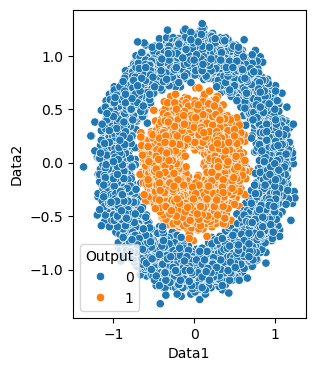

In [4]:
plt.figure(figsize=(3,4))
sns.scatterplot( x="Data1" , y = "Data2" , data=dataset , hue="Output")
plt.show()

In [5]:
x = dataset.iloc[:,:-1]
y = dataset["Output"]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train , x_test , y_train , y_test = train_test_split( x , y , test_size=0.2 , random_state=42)

In [8]:
from sklearn.svm import SVC 

In [17]:
sv = SVC(kernel="rbf")
sv.fit(x_train , y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
sv.score(x_test , y_test)*100

99.85000000000001

In [19]:
sv.score(x_train , y_train)*100

99.8625

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


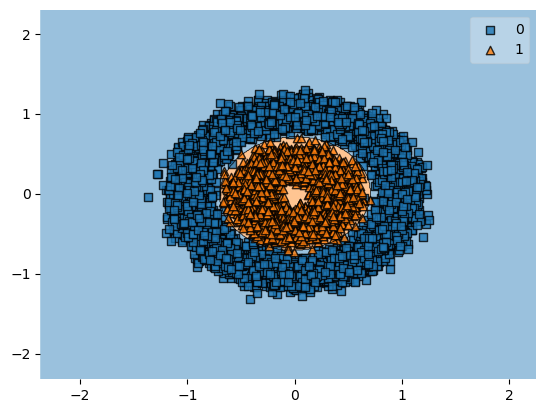

In [22]:
plot_decision_regions( x.to_numpy() , y.to_numpy() ,clf=sv )
plt.show()